# Purpose:
- Running another round of landmark extension.
- Based on the 1st iteration, where no GFP threshold was used.
    - Now set the threshold based on QC'ed ROIs.
    - Now simply use distance matrix. Don't iterate, make one matrix, and match all at once.
        - This reduces mismatching between nearby cells.
- Metrics:
    - How many more co-registered cells after another iteration?
    - How much does additional manual step help?
# Protocol:
- Filter HCR data based on spot counts and density
- Find nearest matches (greedy method)


In [ ]:
import os
import zarr
import numpy as np
import tifffile as tiff
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import Rbf
from scipy.spatial import distance_matrix
import cv2
import os
import json
from pathlib import Path

In [ ]:
def get_hcr_data_asset_path(mouse_id, data_path, round=1):
    data_path = Path(data_path)
    HCR_data_assets = [f for f in np.sort(os.listdir(data_path)) if f'HCR_{mouse_id}' in f and 'processed' in f]
    HCR_data_asset = HCR_data_assets[round-1]
    return data_path / HCR_data_asset

def get_hcr_scales(mouse_id, data_path, round=1):
    hcr_data_asset_path = get_hcr_data_asset_path(mouse_id, data_path, round)

    json_file = [hcr_data_asset_path / f for f in os.listdir(hcr_data_asset_path) if f.endswith('_ng.json')][0]
    with open(json_file, 'r') as file:
        data = json.load(file)

    scale_x = data['dimensions']['x'][0]*4e6
    scale_y = data['dimensions']['y'][0]*4e6
    scale_z = data['dimensions']['z'][0]*1e6

    return scale_x, scale_y, scale_z


def get_hcr_centroids_df(mouse_id, code_path):
    coreg_path = code_path / f'{mouse_id}_coreg'
    fn = coreg_path / f'{mouse_id}_HCR_cell_centroids.csv'
    if not fn.exists():
        fn = code_path / f'{mouse_id}_HCR_cell_centroids.csv'
        assert fn.exists(), f'Centroid file not found: {fn}'
    HCR_cell_centroids_df = pd.read_csv(fn).set_index('hcr_cell_id',drop=True)
    return HCR_cell_centroids_df


def generate_hcr_centroids_df(mouse_id, data_path):
    hcr_data_asset_path = get_hcr_data_asset_path(mouse_id, data_path)

    HCR_cell_centroids = np.load(hcr_data_asset_path / 'cell_body_segmentation/cell_centroids.npy')

    HCR_cell_ids = HCR_cell_centroids[:,3]
    HCR_cell_centroids = HCR_cell_centroids[:,:-1]

    HCR_cell_centroids_df = pd.DataFrame()
    HCR_cell_centroids_df['hcr_cell_id'] = HCR_cell_ids
    HCR_cell_centroids_df['hcr_z'] = HCR_cell_centroids[:,0]
    HCR_cell_centroids_df['hcr_y'] = HCR_cell_centroids[:,1]
    HCR_cell_centroids_df['hcr_x'] = HCR_cell_centroids[:,2]
    HCR_cell_centroids_df.set_index('hcr_cell_id', inplace=True)

    return HCR_cell_centroids_df

In [3]:
def get_ids_from_landmarks(landmarks):
    columns = ['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']
    assert len(landmarks.columns) == len(columns)
    if not all([a==b for a,b in zip(landmarks.columns, columns)]):
        landmarks.columns = columns
    matched_ids = landmarks['ids'].values
    def _get_ids(x):
        if x.startswith('cz'):
            cz_id = int(x.split('-')[0].split('cz')[-1])
            hcr_id = int(x.split('-')[1].split('hcr')[-1])
            return cz_id, hcr_id
        else:
            return -1
    
    ids = [_get_ids(x) for x in matched_ids]
    ids = [id for id in ids if id != -1]
    zstack_ids = [id[0] for id in ids]
    hcr_ids = [id[1] for id in ids]
    return zstack_ids, hcr_ids

In [4]:
data_path = Path('/root/capsule/data/')
code_path = Path('/root/capsule/code/')
mouse_id = 767018
coreg_dir = code_path / f'{mouse_id}_coreg'
hcr_asset_path = get_hcr_data_asset_path(mouse_id, data_path)

HCR_cell_centroids_df = get_hcr_centroids_df(mouse_id, code_path)
scale_x, scale_y, scale_z = get_hcr_scales(mouse_id, data_path)

In [5]:
HCR_cell_centroids_df.head()

,hcr_z,hcr_y,hcr_x
hcr_cell_id,,,
1,33,756,182
2,107,296,103
3,116,194,113
4,116,320,90
5,117,184,104


In [6]:
# czstack_seg_data_asset = [f for f in np.sort(os.listdir(data_path)) if f'multiplane-ophys_{mouse_id}' in f and 'cortical-zstack-seg' in f][0]
# czstack_masks_file = data_path / czstack_seg_data_asset / 'channel_0_ref_0/segmentation_masks.tif'
# czstack_masks = tiff.imread(czstack_masks_file)

# get the outline file because it should have been generated in the previous iteration
# outline_file = next(code_path.rglob(f'{mouse_id}_seg_masks_outline.tif'))
# czstack_masks_outline = tiff.imread(outline_file)

# get centroids dataframe
czstack_centroid_fn = next(code_path.rglob(f'{mouse_id}_czstack_cell_centroids.csv'))
czstack_cell_centroids_df = pd.read_csv(czstack_centroid_fn).set_index('czstack_cell_id',drop=True)
czstack_cell_centroids = np.vstack(czstack_cell_centroids_df[['czstack_z','czstack_y','czstack_x']].values)

# get spots dataframe
spots_488_file = hcr_asset_path / 'image_spot_detection/channel_488_spots/spots.csv'
spots_488 = pd.read_csv(spots_488_file)


In [9]:
# Get landmarks from the previous iteration
current_iter = 2
prev_iter = current_iter - 1
# landmarks_file = next(coreg_dir.glob(f'{mouse_id}_landmarks_matched_ext_iter{prev_iter}.csv'))
landmarks_file = next(coreg_dir.glob(f'{mouse_id}_landmarks_matched_ext_iter{prev_iter}_reordered_qced.csv'))

landmarks = pd.read_csv(landmarks_file,header=None)
columns = ['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']
landmarks.columns = columns
landmarks = landmarks.query('active')

points_zstack = landmarks[['czstack_x', 'czstack_y', 'czstack_z']].values.astype(np.float32)
points_HCR = landmarks[['hcr_x', 'hcr_y', 'hcr_z']].values.astype(np.float32)

matched_czstack_ids, matched_hcr_ids = get_ids_from_landmarks(landmarks)
leftover_czstack_ids = list(set(czstack_cell_centroids_df.index) - set(matched_czstack_ids))
leftover_czstack_df = czstack_cell_centroids_df.loc[leftover_czstack_ids]
leftover_czstack_cell_centroids = np.vstack(leftover_czstack_df[['czstack_x','czstack_y','czstack_z']].values)

interp_zstacktoHCR_0 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,0], function='thin_plate')
interp_zstacktoHCR_1 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,1], function='thin_plate')
interp_zstacktoHCR_2 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,2], function='thin_plate')

HCR_centroids_est = np.zeros_like(leftover_czstack_cell_centroids)

HCR_centroids_est[:,0] = interp_zstacktoHCR_0(leftover_czstack_cell_centroids[:, 0], leftover_czstack_cell_centroids[:, 1], leftover_czstack_cell_centroids[:, 2])/scale_x
HCR_centroids_est[:,1] = interp_zstacktoHCR_1(leftover_czstack_cell_centroids[:, 0], leftover_czstack_cell_centroids[:, 1], leftover_czstack_cell_centroids[:, 2])/scale_y
HCR_centroids_est[:,2] = interp_zstacktoHCR_2(leftover_czstack_cell_centroids[:, 0], leftover_czstack_cell_centroids[:, 1], leftover_czstack_cell_centroids[:, 2])/scale_z


In [7]:
spot_488_counts = pd.DataFrame(spots_488['SEG_ID'].value_counts())
spot_488_bounding_box_min = spots_488.groupby('SEG_ID').agg({'X':'min','Y':'min','Z':'min'}).rename(columns={'X':'min_x','Y':'min_y','Z':'min_z'})
spot_488_bounding_box_max = spots_488.groupby('SEG_ID').agg({'X':'max','Y':'max','Z':'max'}).rename(columns={'X':'max_x','Y':'max_y','Z':'max_z'})
spot_488_bounding_box = pd.concat([spot_488_bounding_box_min, spot_488_bounding_box_max], axis=1)
spot_488_bounding_box['bb_volume'] = (spot_488_bounding_box['max_x'] - spot_488_bounding_box['min_x'] + 1) * (spot_488_bounding_box['max_y'] - spot_488_bounding_box['min_y'] + 1) * (spot_488_bounding_box['max_z'] - spot_488_bounding_box['min_z'] + 1)
spot_488_counts = spot_488_counts.merge(spot_488_bounding_box[['bb_volume']], left_index=True, right_index=True)

In [8]:
spot_488_counts['density'] = spot_488_counts['count'] / spot_488_counts['bb_volume']
spot_488_counts.head()

,count,bb_volume,density
SEG_ID,,,
95255,1476,1245972,0.001185
22366,1379,888444,0.001552
70320,1269,994032,0.001277
47785,1262,772200,0.001634
98899,1193,783216,0.001523


In [10]:
matched_spot_counts = spot_488_counts.loc[matched_hcr_ids]
matched_spot_counts.head()

,count,bb_volume,density
SEG_ID,,,
9906,288,128340,0.002244
9874,538,346940,0.001551
7239,471,203300,0.002317
9359,289,166668,0.001734
8639,248,115056,0.002155


In [11]:
nonmatched_spot_counts = spot_488_counts.drop(index=matched_hcr_ids)
nonmatched_spot_counts.head()

,count,bb_volume,density
SEG_ID,,,
95255,1476,1245972,0.001185
22366,1379,888444,0.001552
70320,1269,994032,0.001277
47785,1262,772200,0.001634
98899,1193,783216,0.001523


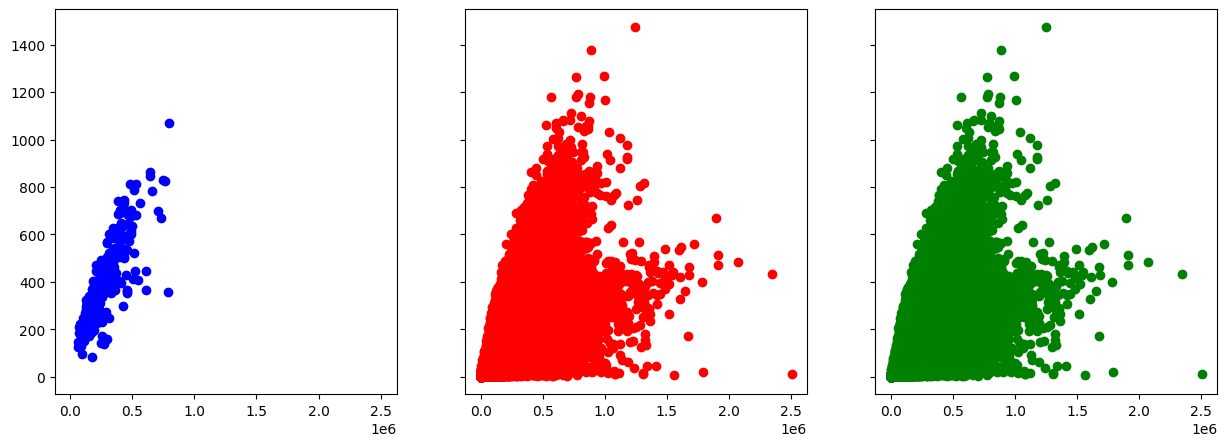

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15,5), sharex=True, sharey=True)
ax[0].scatter(matched_spot_counts['bb_volume'], matched_spot_counts['count'], color='blue', label='Matched')
ax[1].scatter(nonmatched_spot_counts['bb_volume'], nonmatched_spot_counts['count'], color='red', label='Non-Matched')
ax[2].scatter(spot_488_counts['bb_volume'], spot_488_counts['count'], color='green', label='All')

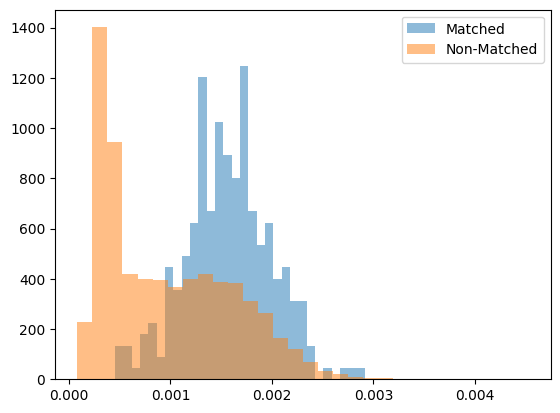

In [13]:

fig, ax = plt.subplots()
ax.hist(matched_spot_counts.query('count>80')['density'], bins=30, alpha=0.5, label='Matched', density=True)
ax.hist(nonmatched_spot_counts.query('count>80')['density'], bins=30, alpha=0.5, label='Non-Matched', density=True)
# ax.hist(spot_488_counts.query('count>80')['density'], bins=30, alpha=0.5, label='All')
ax.legend()

In [14]:
matched_spot_counts['count'].min()

np.int64(84)

In [15]:
matched_spot_counts['bb_volume'].min()

np.int64(63756)

In [19]:
matched_spot_counts['bb_volume'].max()

np.int64(792528)

In [16]:
matched_spot_counts['density'].min()

np.float64(0.00045292498192106166)

In [28]:
min_counts = matched_spot_counts['count'].min() * 0.9
min_density = matched_spot_counts['density'].min() * 0.9
leftover_spot_counts = nonmatched_spot_counts.query('count >= @min_counts and density >= @min_density')
leftover_spot_counts.head()

,count,bb_volume,density
SEG_ID,,,
95255,1476,1245972,0.001185
22366,1379,888444,0.001552
70320,1269,994032,0.001277
47785,1262,772200,0.001634
98899,1193,783216,0.001523


In [29]:
leftover_spot_counts.bb_volume.max()

np.int64(1320336)

In [ ]:
leftover_HCR_df = pd.merge(leftover_spot_counts, HCR_cell_centroids_df, left_index=True, right_index=True, how='inner')


In [21]:
# One-to-One Matching Algorithm
# Solves the many-to-one problem by iteratively assigning best matches

def one_to_one_matching(dist_matrix):
    """
    Solve one-to-one matching from distance matrix.
    
    Parameters:
    -----------
    dist_matrix : ndarray of shape (M, N)
        Distance matrix where M is number of source points (HCR_centroids_est)
        and N is number of target points (hcr_centroids)
    
    Returns:
    --------
    matched_indices : ndarray of shape (M,)
        Index of matched target point for each source point (-1 if unmatched)
    matched_distances : ndarray of shape (M,)
        Distance to matched target point for each source point (inf if unmatched)
    """
    M, N = dist_matrix.shape
    
    # Initialize output arrays
    matched_indices = np.full(M, -1, dtype=int)
    matched_distances = np.full(M, np.inf)
    
    # Keep track of which target points are already assigned
    used_targets = np.zeros(N, dtype=bool)
    
    # Create a copy of distance matrix that we can modify
    working_dist_matrix = dist_matrix.copy()
    
    # Process matches iteratively
    for iteration in range(min(M, N)):
        # Find the global minimum in the remaining matrix
        flat_idx = np.argmin(working_dist_matrix)
        source_idx, target_idx = np.unravel_index(flat_idx, working_dist_matrix.shape)
        
        # Record this match
        matched_indices[source_idx] = target_idx
        matched_distances[source_idx] = working_dist_matrix[source_idx, target_idx]
        
        # Mark this target as used
        used_targets[target_idx] = True
        
        # Remove this source row and target column from consideration
        working_dist_matrix[source_idx, :] = np.inf
        working_dist_matrix[:, target_idx] = np.inf
    
    return matched_indices, matched_distances



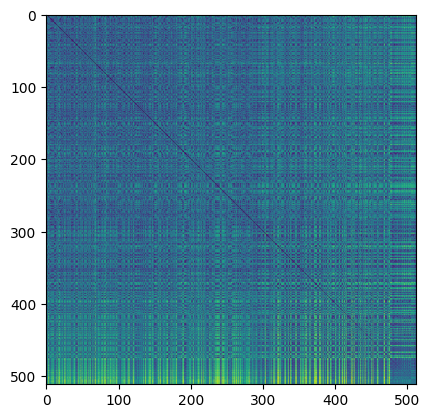

In [ ]:
hcr_centroids = leftover_HCR_df[['hcr_x','hcr_y','hcr_z']].values # x,y,z order
# calculate pairwise distances

dist_matrix = distance_matrix(HCR_centroids_est, hcr_centroids)
final_matched_indices, final_matched_distances = one_to_one_matching(dist_matrix)

sort_order = np.argsort(final_matched_distances)
    
# Create matrix with matched sources (rows) and their assigned targets (columns)
sorted_sources = np.arange(len(final_matched_indices))[sort_order]
sorted_targets = final_matched_indices[sort_order]
sorted_dists = final_matched_distances[sort_order]

# Extract relevant distances for visualization
matched_dist_matrix = dist_matrix[np.ix_(sorted_sources, sorted_targets)]

plt.imshow(matched_dist_matrix)



In [39]:
HCR_df.head()

,count,bb_volume,density,hcr_z,hcr_y,hcr_x
95255,1476,1245972,0.001185,1157,197,2070
22366,1379,888444,0.001552,578,381,1833
70320,1269,994032,0.001277,975,137,2113
47785,1262,772200,0.001634,815,2143,1075
98899,1193,783216,0.001523,1191,779,2078


In [32]:
# assign matching to matched_cells_df
new_matched_hcr_df = HCR_df.iloc[final_matched_indices].reset_index().copy().rename(columns={'index':'hcr_cell_id'})
new_matched_hcr_df['distance'] = final_matched_distances
new_matched_hcr_df['czstack_cell_id'] = leftover_czstack_ids
new_matched_hcr_df['czstack_x'] = leftover_czstack_df['czstack_x'].values
new_matched_hcr_df['czstack_y'] = leftover_czstack_df['czstack_y'].values
new_matched_hcr_df['czstack_z'] = leftover_czstack_df['czstack_z'].values
new_matched_hcr_df.sort_values(by='distance', inplace=True)
new_matched_hcr_df.head()


,hcr_cell_id,count,bb_volume,density,hcr_z,hcr_y,hcr_x,distance,czstack_cell_id,czstack_x,czstack_y,czstack_z
391,99538,273,235980,0.001157,1198,1347,807,1.447762,660,473.140722,149.814134,301.084682
233,57439,284,151152,0.001879,890,860,1291,1.595701,397,54.580479,433.743004,199.382583
300,78071,133,121275,0.001097,1026,1384,828,1.814382,525,467.016733,117.451793,251.949801
67,10236,257,112832,0.002278,370,1428,859,1.876545,79,484.084301,79.188502,65.717247
175,28059,300,194184,0.001545,634,1501,911,1.977212,267,436.163760,18.263316,145.240964


In [33]:
landmarks

,ids,active,czstack_x,czstack_y,czstack_z,hcr_x,hcr_y,hcr_z
6,Pt-15,True,24.731497,504.394099,68.917517,1322.547936,741.335282,420.829982
10,Pt-19,True,387.061294,68.739985,197.319963,934.241818,1414.927529,838.457175
15,Pt-6,True,246.062983,16.725618,156.031364,1148.513888,1449.274401,657.501248
20,cz0002-hcr9906,True,263.569199,461.115564,34.607875,994.426443,858.284728,358.000000
21,cz0003-hcr9874,True,321.975682,366.566333,36.813024,981.601499,962.857349,355.000000
...,...,...,...,...,...,...,...,...
815,Pt-816,True,483.479430,403.515004,44.274563,797.209641,945.554563,305.925948
816,Pt-817,True,455.503668,472.383220,32.569388,812.626915,870.173731,321.899945
817,Pt-818,True,399.707079,457.509312,78.881111,836.184290,890.160373,449.121282
818,Pt-819,True,468.981482,483.050130,271.845944,716.769844,878.678045,1141.109799


In [41]:
save_fn = coreg_dir / f'{mouse_id}_landmarks_matched_ext_iter{current_iter}.csv'
landmarks_ext = pd.DataFrame()

landmarks_ext[0] = ['cz'+str(int(new_matched_hcr_df['czstack_cell_id'].iloc[i]))+'-hcr'+str(int(new_matched_hcr_df['hcr_cell_id'].iloc[i])) for i in range(len(new_matched_hcr_df))]

landmarks_ext[1] = False
landmarks_ext[2] = new_matched_hcr_df['czstack_x'].values
landmarks_ext[3] = new_matched_hcr_df['czstack_y'].values
landmarks_ext[4] = new_matched_hcr_df['czstack_z'].values
landmarks_ext[5] = new_matched_hcr_df['hcr_x'].values * scale_x
landmarks_ext[6] = new_matched_hcr_df['hcr_y'].values * scale_y
landmarks_ext[7] = new_matched_hcr_df['hcr_z'].values * scale_z

columns = np.arange(8)
landmarks.columns = columns
landmarks_ext = pd.concat([landmarks_ext, landmarks])

landmarks_ext.to_csv(save_fn, index=False, header=False)
landmarks_ext.head()

,0,1,2,3,4,5,6,7
0,cz660-hcr99538,False,473.140722,149.814134,301.084682,796.133075,1328.861526,1198.0
1,cz397-hcr57439,False,54.580479,433.743004,199.382583,1273.615613,848.419386,890.0
2,cz525-hcr78071,False,467.016733,117.451793,251.949801,816.850292,1365.363291,1026.0
3,cz79-hcr10236,False,484.084301,79.188502,65.717247,847.432852,1408.770794,370.0
4,cz267-hcr28059,False,436.163760,18.263316,145.240964,898.732628,1480.787789,634.0


In [35]:
def _get_hcr_id(x):
    if x.startswith('cz'):
        return int(x.split('-hcr')[-1])
    else:
        return -1
landmarks_ext['hcr_id'] = landmarks_ext[0].apply(_get_hcr_id)

In [38]:
pd.DataFrame(landmarks_ext.query('hcr_id != -1').hcr_id.value_counts()).query('count == 2')

,count
hcr_id,
